# **Finding Corners**

## **Objectives:**
1. To use Harris Corners to find corners
2. Use Good Features to Track


> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **What is a Corner?**

A corner is a point whose local neighborhood stands in two dominant and different edge directions. In other words, a corner can be interpreted as the junction of two edges, where an edge is a sudden change in image brightness. Corners are the important features in the image, and they are generally termed as interest points which are invariant to translation, rotation, and illumination.

### **Harris Corner Detection** is an algorithm developed in 1988 for corner detection that works fairly well.


**Paper** - http://www.bmva.org/bmvc/1988/avc-88-023.pdf

**cv2.cornerHarris**(input image, block size, ksize, k)
- Input image - should be grayscale and float32 type.
- blockSize - the size of neighborhood considered for corner detection
- ksize - aperture parameter of Sobel derivative used.
- k - harris detector free parameter in the equation


- **Output** – array of corner locations (x,y)

### Why corners specifically — not edges, not flat regions

Harris' test: imagine sliding a small window over the image in *every* direction and measuring how much the pixels underneath it change.

- **Flat region** (sky, a wall) — shift the window any direction, pixels barely change. No good keypoint; nothing to distinguish this spot from its neighbor.
- **Edge** — shift *along* the edge, nothing changes (everything still looks like the same edge); shift *across* it, big change. Change in only one direction still isn't enough to pin down a precise location — you could slide along the edge and get an equally good match.
- **Corner** — shift in *any* direction and the window changes a lot. That's the only case that pins down an exact, unambiguous location — which is exactly why corners make good features to track (notebook 25's optical flow starts from `goodFeaturesToTrack`, this same idea) or match between two images.

Harris turns "changes a lot in every direction" into two numbers — the eigenvalues (λ₁, λ₂) of a small matrix built from the local gradients. Both small → flat. One large, one small → edge. Both large → corner. `cv2.cornerHarris` combines them into a single response score, `R = λ₁λ₂ − k(λ₁+λ₂)²`, and the `0.025 * harris_corners.max()` threshold in the next cell is keeping only the pixels whose R-score lands firmly in corner territory:

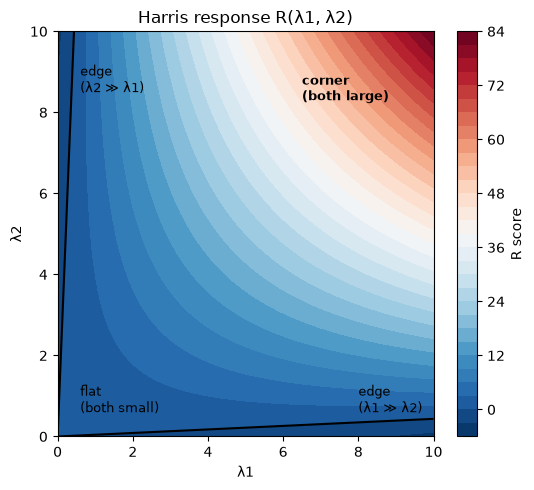

In [2]:
import numpy as np
import matplotlib.pyplot as plt

l1 = np.linspace(0, 10, 300)
l2 = np.linspace(0, 10, 300)
L1, L2 = np.meshgrid(l1, l2)
k = 0.04
R = (L1 * L2) - k * (L1 + L2)**2

fig, ax = plt.subplots(figsize=(5.5, 5))
cs = ax.contourf(L1, L2, R, levels=30, cmap='RdBu_r')
ax.contour(L1, L2, R, levels=[0], colors='black', linewidths=1.5)
ax.set_xlabel('λ1'); ax.set_ylabel('λ2')
ax.set_title('Harris response R(λ1, λ2)')
ax.text(0.6, 0.6, 'flat\n(both small)', color='black', fontsize=9)
ax.text(8, 0.6, 'edge\n(λ1 ≫ λ2)', color='black', fontsize=9)
ax.text(0.6, 8.5, 'edge\n(λ2 ≫ λ1)', color='black', fontsize=9)
ax.text(6.5, 8.3, 'corner\n(both large)', color='black', fontsize=9, weight='bold')
plt.colorbar(cs, ax=ax, label='R score')
plt.tight_layout()
plt.show()

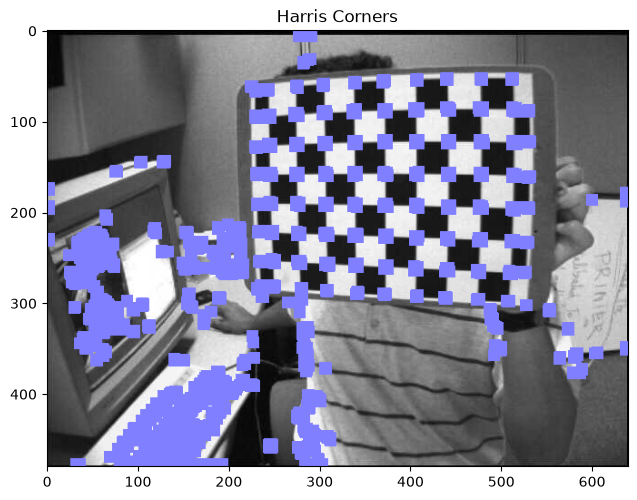

In [3]:
# Load image then grayscale
image = cv2.imread('assets/images/chess.JPG')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# The cornerHarris function requires the array datatype to be float32
gray = np.float32(gray)

harris_corners = cv2.cornerHarris(gray, 3, 3, 0.05)

#We use dilation of the corner points to enlarge them\
kernel = np.ones((7,7),np.uint8)
harris_corners = cv2.dilate(harris_corners, kernel, iterations = 2)

# Threshold for an optimal value, it may vary depending on the image.
image[harris_corners > 0.025 * harris_corners.max() ] = [255, 127, 127]

imshow('Harris Corners', image)

**cv2.goodFeaturesToTrack**(input image, maxCorners, qualityLevel, minDistance)

- Input Image - 8-bit or floating-point 32-bit, single-channel image.
- maxCorners – Maximum number of corners to return. If there are more corners than are found, the strongest of them is returned.
- qualityLevel – Parameter characterizing the minimal accepted quality of image corners. The parameter value is multiplied by the best corner quality measure (smallest eigenvalue). The corners with the quality measure less than the product are rejected. For example, if the best corner has the quality measure = 1500, and the  qualityLevel=0.01 , then all the corners with the quality - - measure less than 15 are rejected.
- minDistance – Minimum possible Euclidean distance between the returned corners.

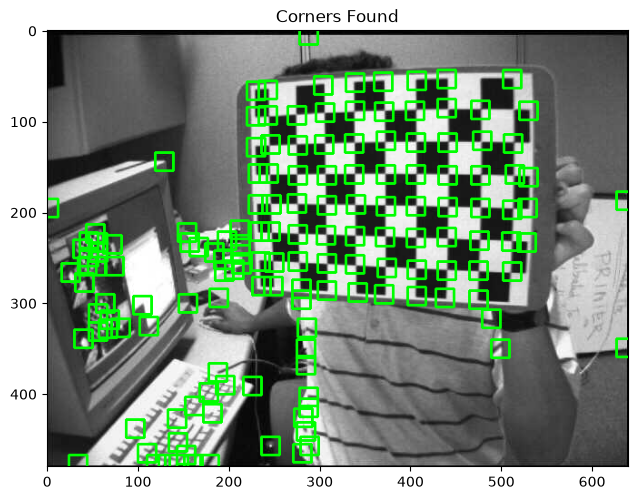

In [4]:
img = cv2.imread('assets/images/chess.JPG')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# We specific the top 50 corners
corners = cv2.goodFeaturesToTrack(gray, 150, 0.0005, 10)

for corner in corners:
    x, y = corner[0]
    x = int(x)
    y = int(y)
    cv2.rectangle(img,(x-10,y-10),(x+10,y+10),(0,255,0), 2)
    
imshow("Corners Found", img)

### A few ideas to play with

- Sub-pixel refine the Harris corners with `cv2.cornerSubPix` — the raw corners are accurate to the nearest pixel, sub-pixel refinement gets you fractional precision, which matters a lot for camera calibration.
- `cv2.goodFeaturesToTrack` accepts a `mask` — restrict corner search to just the left half of `images/chess.JPG` and confirm none show up on the right.